In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
iris = load_iris()
x = iris.data
y = iris.target
xtr, xte, ytr, yte = train_test_split(x, y, test_size = 0.2, random_state = 33550336, stratify = y)

In [5]:
def tempt(x, y, classs):
    dic = {}
    adic = {}
    for i in range(len(y)):
        if y[i] not in dic:
            dic[y[i]] = 0
        if y[i] not in adic:
            adic[y[i]] = []
        dic[y[i]] += 1
        adic[y[i]].append(i)
    prs = []
    mnss = []
    varr = []
    for k in classs:
        prior = dic[k] / len(y)
        newa = x[adic[k]]
        mns = np.mean(newa, axis = 0)
        var = np.mean((newa - mns)**2, axis = 0) + 1e-9
        prs.append(prior)
        mnss.append(mns)
        varr.append(var)
    return prs, mnss, varr

In [6]:
prs, mnss, varr = tempt(xtr, ytr, np.unique(ytr))

In [7]:
np.shape(varr)

(3, 4)

In [8]:
def gas(x, mn, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mn)**2 / (2 * var))

In [9]:
def loggas(x, mn, var):
    return -1/2 * np.log(2 * np.pi * var) - ((x - mn) ** 2)/(2 * var)

In [10]:
def cs(x, p, m, v, classs):
    sms = []
    for k in classs:
        li = loggas(x, m[k], v[k])
        sm = np.sum(li) + np.log(p[k])
        sms.append(sm)
    return sms

In [11]:
cs(xte[0], prs, mnss, varr, np.unique(ytr))

[np.float64(-321.09372024121274),
 np.float64(-5.872609979698642),
 np.float64(-2.8038653539272733)]

In [12]:
def preds(x, p, m, v, classs):
    scores = []
    for i in range(len(x)):
        stuff = cs(x[i], p, m, v, classs)
        mx = -1000000000 
        bestidx = -1000
        for j in range(len(stuff)):
            if stuff[j] > mx:
                bestidx = j
                mx = stuff[j]
        scores.append(bestidx)
    return scores

In [13]:
scores = preds(xte, prs, mnss, varr, np.unique(ytr))
accracy = accuracy_score(scores, yte)
print(f"Accuracy: {accracy}")

Accuracy: 0.9


In [14]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

In [15]:
categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.space",
    "talk.politics.mideast"
]

In [16]:
train = fetch_20newsgroups(
    subset="train",
    categories=categories
)

test = fetch_20newsgroups(
    subset="test",
    categories=categories
)

In [17]:
tfidf = TfidfVectorizer(max_features = 1000)

In [18]:
xtr = tfidf.fit_transform(train.data)
xte = tfidf.transform(test.data)
xtr = xtr.toarray()
xte = xte.toarray()
ytr = train.target
yte = test.target
p, m, v = tempt(xtr, ytr, np.unique(ytr))

In [19]:
np.min(v)

np.float64(1e-09)

In [20]:
np.unique(ytr)

array([0, 1, 2, 3])

In [21]:
cs(xte[0], p, m, v, np.unique(ytr))

[np.float64(2657.921367289),
 np.float64(3142.6540576069883),
 np.float64(2108.5007803000044),
 np.float64(-1838.362371286578)]

In [22]:
score = preds(xte, p, m, v, np.unique(ytr))
accracy = accuracy_score(score, yte)
print(f"Accuracy: {accracy}")

Accuracy: 0.8946015424164524


In [23]:
confusion_matrix(yte, score)

array([[325,  15,  44,   5],
       [  7, 353,  26,  11],
       [ 12,  12, 367,   3],
       [  4,  17,   8, 347]])

In [24]:
x = iris.data
y = iris.target
k = 3
idx = rng.integers(0, 150)

In [25]:
ds = []
for i in range(150):
    tmp = (x[i] - x[131]) ** 2
    ds.append(np.sum(tmp))

sm = np.sum(ds)
ps = []
for i in range(150):
    tmp = ds[i]/sm
    ps.append(tmp)
np.sum(ps)

np.float64(1.0)

In [26]:
idx2 = np.random.choice(150, p = ps)

In [27]:
ds2 = []
for i in range(150):
    d1 = np.sum((x[i] - x[131]) ** 2)
    d2 = np.sum((x[i] - x[89]) ** 2)
    ds2.append(min(d1, d2))
ps2 = []
for i in range(150):
    tmp = ds2[i]/np.sum(ds2)
    ps2.append(tmp)
np.sum(ps2)

np.float64(1.0000000000000002)

In [28]:
idx3 = np.random.choice(150, p = ps2)

In [29]:
idx3

47

In [30]:
centroids = np.array([x[131], x[89], x[47]])
np.shape(centroids)

(3, 4)

In [31]:
clusters = []
for i in range(150):
    mus = []
    for cent in centroids:
        tmp = np.sum((x[i] - cent) ** 2)
        mus.append(tmp)
    mx = 10000000
    clus = -1
    for j in range(len(mus)):
        mu = mus[j]
        if mu < mx:
            mx = mu
            clus = j
    clusters.append(clus)

In [32]:
len(clusters)

150

In [33]:
np.unique(clusters, return_counts = True)

(array([0, 1, 2]), array([31, 69, 50]))

In [34]:
def cnts(y):
    dic = {}
    adic = {}
    for i in range(len(y)):
        if y[i] not in dic:
            dic[y[i]] = 0
        if y[i] not in adic:
            adic[y[i]] = []
        dic[y[i]] += 1
        adic[y[i]].append(i)
    return dic, adic

In [35]:
dic, adic = cnts(clusters)

In [36]:
nc = []
for i in range(len(np.unique(clusters))):
    cnt = 0
    s = 0
    for idx in adic[i]:
        s += x[idx]
        cnt += 1
    mn = s/cnt
    nc.append(mn)

In [37]:
np.array(nc).shape

(3, 4)

In [38]:
nc = np.array(nc)

In [39]:
moves = np.sqrt(np.sum((centroids - nc) ** 2, axis = 1))

In [40]:
moves

array([1.31714856, 0.73580668, 0.47199576])

In [41]:
centroids = nc
clusters = []
for i in range(150):
    mus = []
    for cent in centroids:
        tmp = np.sum((x[i] - cent) ** 2)
        mus.append(tmp)
    mx = 10000000
    clus = -1
    for j in range(len(mus)):
        mu = mus[j]
        if mu < mx:
            mx = mu
            clus = j
    clusters.append(clus)
    
dic, adic = cnts(clusters)
nc = []
for i in range(len(np.unique(clusters))):
    cnt = 0
    s = 0
    for idx in adic[i]:
        s += x[idx]
        cnt += 1
    mn = s/cnt
    nc.append(mn)


nc = np.array(nc)
moves = np.sqrt(np.sum((centroids - nc) ** 2, axis = 1))
moves

array([0.09119218, 0.06547337, 0.        ])

In [42]:
moves = np.sqrt(np.sum((centroids - nc) ** 2, axis = 1))

In [43]:
moves

array([0.09119218, 0.06547337, 0.        ])

In [44]:
centroids = nc
clusters = []
for i in range(150):
    mus = []
    for cent in centroids:
        tmp = np.sum((x[i] - cent) ** 2)
        mus.append(tmp)
    mx = 10000000
    clus = -1
    for j in range(len(mus)):
        mu = mus[j]
        if mu < mx:
            mx = mu
            clus = j
    clusters.append(clus)
    
dic, adic = cnts(clusters)
nc = []
for i in range(len(np.unique(clusters))):
    cnt = 0
    s = 0
    for idx in adic[i]:
        s += x[idx]
        cnt += 1
    mn = s/cnt
    nc.append(mn)


nc = np.array(nc)
moves = np.sqrt(np.sum((centroids - nc) ** 2, axis = 1))
moves

array([0.0732702 , 0.04780629, 0.        ])

In [45]:
centroids = nc
clusters = []
for i in range(150):
    mus = []
    for cent in centroids:
        tmp = np.sum((x[i] - cent) ** 2)
        mus.append(tmp)
    mx = 10000000
    clus = -1
    for j in range(len(mus)):
        mu = mus[j]
        if mu < mx:
            mx = mu
            clus = j
    clusters.append(clus)
    
dic, adic = cnts(clusters)
nc = []
for i in range(len(np.unique(clusters))):
    cnt = 0
    s = 0
    for idx in adic[i]:
        s += x[idx]
        cnt += 1
    mn = s/cnt
    nc.append(mn)


nc = np.array(nc)
moves = np.sqrt(np.sum((centroids - nc) ** 2, axis = 1))
moves

array([0., 0., 0.])

In [46]:
np.unique(clusters, return_counts=True)

(array([0, 1, 2]), array([38, 62, 50]))

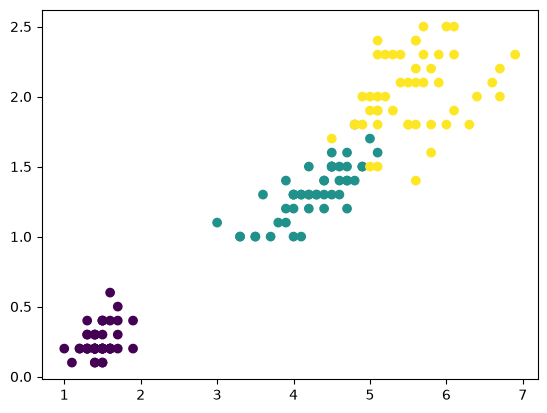

In [47]:
plt.scatter(x[:, 2], x[:, 3], c = y)

In [63]:
covs = np.array([[1, 0], [0, 1]])
blob1 = np.random.multivariate_normal(mean = [-4, -2], cov = covs, size = 100)
blob2 = np.random.multivariate_normal(mean = [0, 4], cov = covs, size = 100)
blob3 = np.random.multivariate_normal(mean = [4, -1], cov = covs, size = 100)

In [64]:
blob = np.vstack((blob1, blob2, blob3))

In [65]:
blob.shape

(300, 2)

In [66]:
m1 = blob[rng.integers(0, 300)]
m2 = blob[rng.integers(0, 300)]
m3 = blob[rng.integers(0, 300)]

In [67]:
means = np.vstack((m1, m2, m3))
cove = np.stack((covs, covs, covs))
pis = np.array([1/3, 1/3, 1/3])

In [68]:
cove.shape

(3, 2, 2)

In [69]:
def gaussian(x, mu, cov):
    d = len(x)
    return 1/((2 * np.pi) ** (d/2) * np.sqrt(np.linalg.det(cov))) * np.exp(-1/2 * (x- mu).T @ np.linalg.inv(cov) @ (x - mu))

In [70]:
gaussian(blob[0], means[0], cove[0])

np.float64(9.09185257490919e-19)

In [71]:
cove[0]

array([[1, 0],
       [0, 1]])

In [72]:
res = []
for i in range(300):    
    x = blob[i]
    probs = []
    for k in range(3):
        probs.append(pis[k] * gaussian(x, means[k], cove[k]))
    res.append(probs * 1/np.sum(probs))
res = np.array(res)

In [74]:
for _ in range(5):
    res = []
    for i in range(300):    
        x = blob[i]
        probs = []
        for k in range(3):
            probs.append(pis[k] * gaussian(x, means[k], cove[k]))
        res.append(probs * 1/np.sum(probs))
    res = np.array(res)
    muns = []
    for k in range(3):
        thingy = res[:, k]
        no = np.sum(thingy, axis = 0)
        mun = np.dot(thingy, blob)/no
        muns.append(mun)
    
    muns = np.array(muns)
    
    coves = []
    for k in range(3):
        summy = np.array([[0.0,0.0], [0.0,0.0]])
    
        no = np.sum(res[:, k])
        for i in range(300):
            diff = blob[i] - muns[k]
            rik = res[i, k]
            coolio = np.outer(diff, diff)
            contrib = coolio * rik
            summy += contrib
        cov = summy / no
        coves.append(cov)
    
    coves = np.array(coves)
    
    newpis = []
    for k in range(3):
        nk = np.sum(res[:, k])
        newpi = nk / 300
        newpis.append(newpi)
    
    newpis = np.array(newpis)
    
    print(np.sqrt(np.sum((muns - means) ** 2, axis = 1)))
    means = muns
    cove = coves
    pis = newpis

[6.20584666e-03 3.92296042e-05 3.62158952e-03]
[1.48120667e-04 7.28705606e-08 1.28462710e-04]
[3.95070091e-06 1.84379678e-09 4.00798866e-06]
[1.13000027e-07 2.05674749e-11 1.20377445e-07]
[3.30396334e-09 4.77672395e-13 3.57321158e-09]


In [81]:
from matplotlib.patches import Ellipse

4.118782233381523
4.785428517502353
-139.54772651158999
3.7842186019107658
4.194708768622363
52.28447046668632
3.5176978115920736
4.242337658935114
84.4206395177319


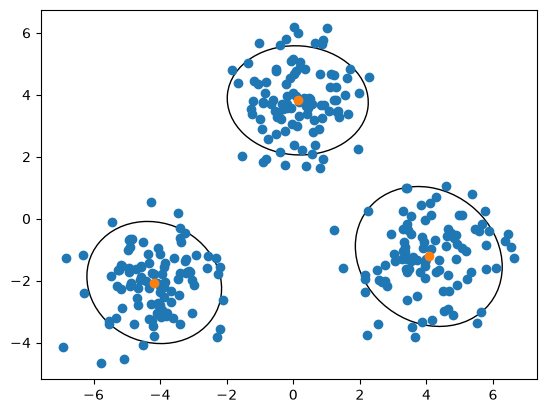

In [84]:
for k in range(3):
    vals, vecs = np.linalg.eigh(cove[k])
    width = 4 * np.sqrt(vals[0])
    height = 4 * np.sqrt(vals[1])
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    print(width)
    print(height)
    print(angle)
    ellipse = Ellipse(
        xy=means[k],
        width=width,
        height=height,
        angle=angle,
        fill=False
    )
    plt.gca().add_patch(ellipse)
plt.scatter(blob[:, 0], blob[:, 1])
plt.scatter(means[:, 0], means[:, 1])


In [85]:
from sklearn.datasets import make_moons

In [89]:
x, y = make_moons(n_samples=300, noise=0.08, random_state=33550336)

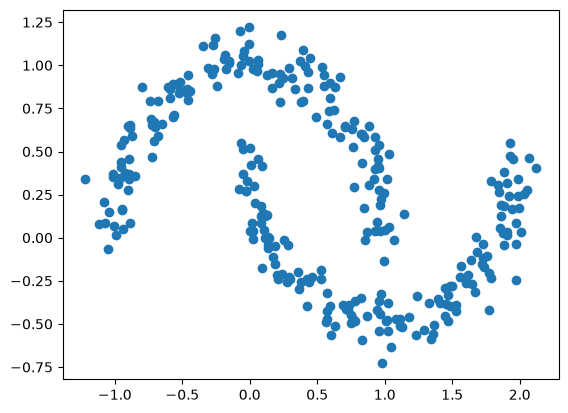

In [90]:
plt.scatter(x[:, 0], x[:, 1])

In [91]:
from sklearn.cluster import KMeans

In [92]:
model = KMeans(n_clusters = 2, random_state = 33550336)
preds = model.fit_predict(x)

C:\Users\leo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


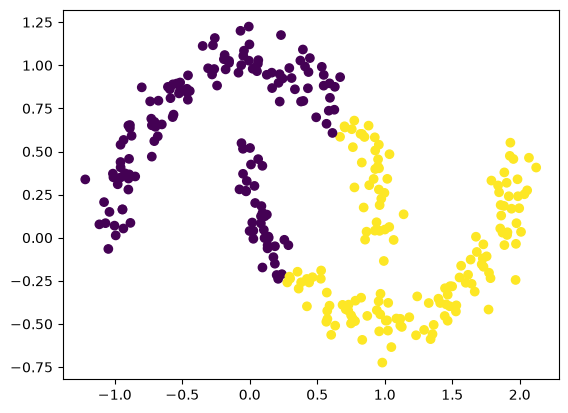

In [93]:
plt.scatter(x[:, 0], x[:, 1], c=preds)

In [94]:
from sklearn.mixture import GaussianMixture

C:\Users\leo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


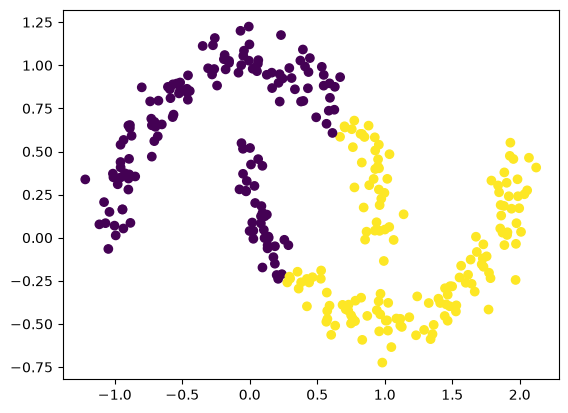

In [95]:
model = GaussianMixture(n_components = 2, random_state = 33550336)
pred = model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c = preds)

In [96]:
from sklearn.cluster import DBSCAN

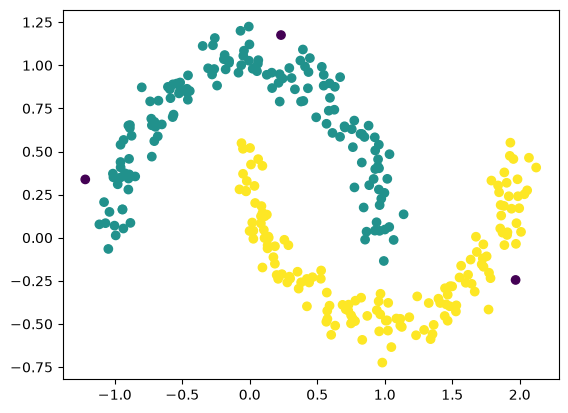

In [102]:
model = DBSCAN(eps = 0.17, min_samples = 5)
preds = model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c = preds)

In [103]:
from sklearn.datasets import make_circles

In [104]:
x, y = make_circles(
    n_samples=300,
    noise=0.05,
    factor=0.5,
    random_state=33550336
)

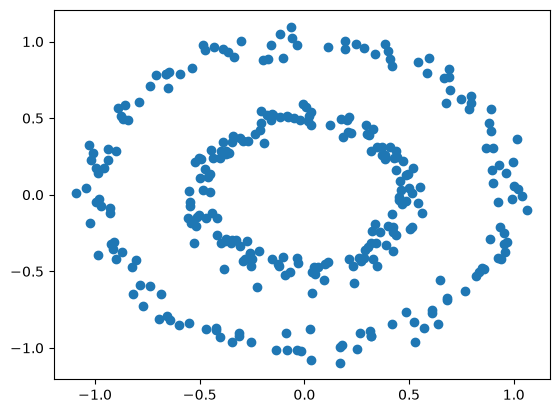

In [105]:
plt.scatter(x[:, 0], x[:, 1])

C:\Users\leo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


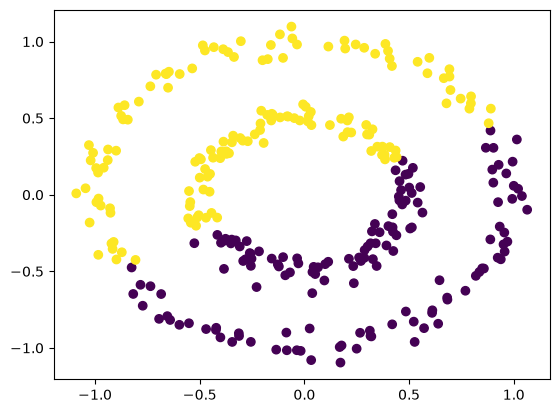

In [106]:
model = KMeans(n_clusters = 2, random_state = 33550336)
preds = model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c = preds)

C:\Users\leo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


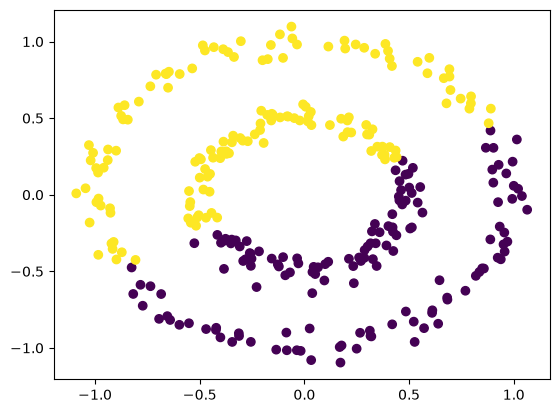

In [107]:
model = GaussianMixture(n_components = 2, random_state = 33550336)
pred = model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c = preds)

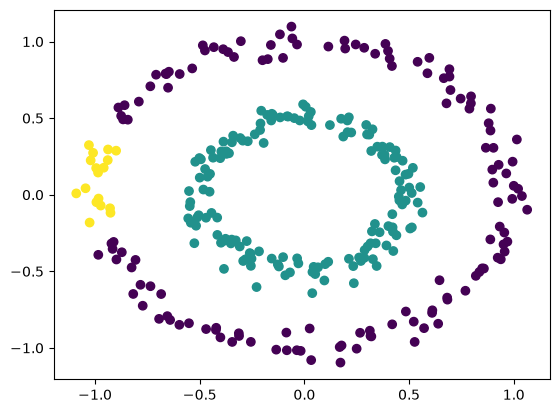

In [108]:
model = DBSCAN(eps = 0.17, min_samples = 5)
preds = model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c = preds)